In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("netflix_titles.csv")
print(df.info())
print(df.head(10))
#print(df.tail())

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None
  show_id     type                             title  \
0      s1    Movie              Dick Johnson Is Dead   
1      s2  TV Show                     Blood & Water   
2      s3  TV Show                         Ganglands   
3      s4  TV Show             Jailbirds New Orleans

In [26]:
print(df.date_added)

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8802     November 20, 2019
8803          July 1, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, Length: 8807, dtype: str


In [27]:
df.date_added =df.date_added.str.strip()


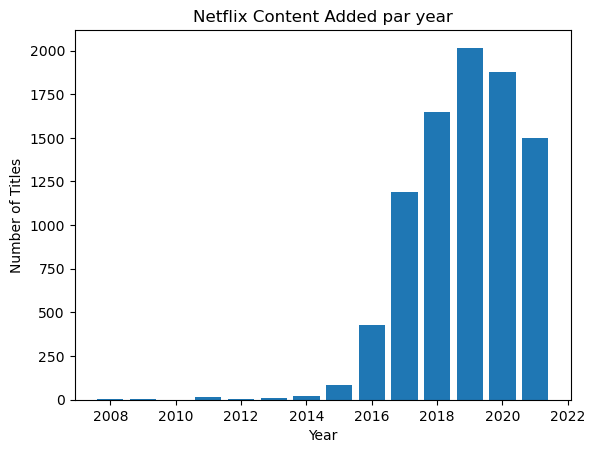

In [37]:
df['date_added'] = pd.to_datetime(df['date_added'],format='%B %d, %Y',errors='coerce')

df['year_added'] = df['date_added'].dt.year
year_count = df['year_added'].value_counts().sort_index()
plt.Figure(figsize=(8,5))
plt.bar(year_count.index,year_count.values)
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.title('Netflix Content Added par year')
plt.show()

In [20]:
netflix = df.groupby("release_year")["type"].sum()
print(netflix)

release_year
1925                                              TV Show
1942                                           MovieMovie
1943                                      MovieMovieMovie
1944                                      MovieMovieMovie
1945                               TV ShowMovieMovieMovie
                              ...                        
2017    MovieTV ShowMovieMovieMovieMovieMovieMovieMovi...
2018    TV ShowTV ShowMovieMovieMovieMovieMovieMovieMo...
2019    TV ShowMovieTV ShowTV ShowTV ShowTV ShowTV Sho...
2020    MovieMovieTV ShowTV ShowTV ShowTV ShowMovieMov...
2021    TV ShowTV ShowTV ShowTV ShowTV ShowMovieTV Sho...
Name: type, Length: 74, dtype: str


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
#df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [4]:
name = df['country']
print(name)

0       United States
1        South Africa
2                 NaN
3                 NaN
4               India
            ...      
8802    United States
8803              NaN
8804    United States
8805    United States
8806            India
Name: country, Length: 8807, dtype: str


In [33]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['date_added']=df['date_added'].fillna(0)

In [29]:
df['date_added'] = df['date_added'].replace(0,np.nan)

In [28]:
df['date_added'].dtype

<StringDtype(storage='python', na_value=nan)>

In [32]:
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

In [34]:
df['date_added'] = df['date_added'].fillna(df['date_added'].median())

In [41]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [40]:
df.fillna({
    'cast': 'Unknown',
    'country':'Unknown',
    'director':'Unknown'
}, inplace=True)



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [36]:
df.loc[df['type']== 'Movie',
       'duration'] =\
 df.loc[df['type']== 'Movie',
        'duration'].fillna('0 min')

df.loc[df['type']== 'Tv',
       'duration'] =\
 df.loc[df['type']== 'Tv',
        'duration'].fillna('0 seasons')            

In [38]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])